# Automated Root Diversity Score (RDS) Pipeline

**Data requirements:** this notebook expects `Dryad.zip` (the Naxerova et al. 2017 discovery-cohort raw data and phylogenies) to be present in the same folder, or you can point `DRYAD_ZIP_PATH` below to its location.

In [ ]:
import json
import math
import re
import zipfile
from math import factorial

from scipy.special import comb
from ete3 import Tree
import pandas as pd

DRYAD_ZIP_PATH = "PATH/Dryad.zip"  # <-- update this path if needed

## 1. Root Diversity Score combinatorics

- `calculate_no_trees(n)` — total number of distinct unrooted bifurcating tree topologies for *n* tips (Edwards & Cavalli-Sforza, 1963)
- `no_trees_min_cluster(k, m, l)` — number of topologies where **at least** *l* of *m* metastases form a single clade
- `rds(k, m, l)` — the Root Diversity Score itself: the probability that such a clade arises by chance alone

In [4]:
def calculate_no_trees(n):
    """Total number of distinct unrooted bifurcating tree topologies for n tips
    (Edwards & Cavalli-Sforza, 1963)."""
    return factorial((2 * n) - 3) / ((2 ** (n - 2)) * factorial(n - 2))


def multibinomial(m, l, cluster_numbers):
    mb = 1
    for c in range(cluster_numbers):
        mb *= comb(m - c * l, l)
    return mb


def no_trees_with_clusters(k, clusters):
    n = k + sum(clusters)
    no_trees = 1
    for c in clusters:
        no_trees *= factorial(2 * c - 3) / (2 ** (c - 2) * factorial(c - 2))
    no_trees *= (factorial((2 * k) + (2 * len(clusters) - 3))
                 / (2 ** (k + (len(clusters) - 2)) * factorial(k + (len(clusters) - 2))))
    return no_trees


def no_trees_min_cluster(k, m, l):
    n = k + m
    if l == 1:
        return calculate_no_trees(n)
    elif l < 1:
        raise RuntimeError(f'l cannot be < 1: {l}')
    no_trees = 0
    for no_clusters in range(1, int(math.floor(m / l) + 1)):
        no_trees += ((-1) ** (no_clusters - 1) * multibinomial(m, l, no_clusters) / factorial(no_clusters)
                     * no_trees_with_clusters(n - (no_clusters * l), [l for _ in range(no_clusters)]))
    return no_trees


def rds(k, m, l):
    """Root Diversity Score: probability that l-out-of-m metastases would
    cluster together by chance alone, given k other samples in the phylogeny."""
    if l == 1:
        return 1.0
    elif l < 1:
        raise RuntimeError(f'l cannot be < 1: {l}')
    n = k + m
    return no_trees_min_cluster(k, m, l) / calculate_no_trees(n)

### 1.1 Self-tests

In [5]:
# Combinatorial sanity checks (from the paper's own unit tests)
assert calculate_no_trees(5) == 105
assert calculate_no_trees(6) == 945
assert no_trees_with_clusters(2, [2, 2]) == 15
assert no_trees_min_cluster(2, 3, 2) == 45
assert no_trees_min_cluster(2, 4, 2) == 585
assert no_trees_min_cluster(2, 6, 2) == 114975
print("All combinatorial self-tests passed.")

All combinatorial self-tests passed.


In [6]:
# RDS regression tests against a sample of independently reported values
# from Supplementary Figs. 1-24 of the paper
example_cases = [
    (11, 4, 3, 0.018), (7, 2, 2, 0.067), (6, 2, 2, 0.08), (9, 2, 2, 0.05),
    (4, 5, 2, 0.59), (6, 5, 5, 0.002), (6, 9, 3, 0.35),
]
for k, m, l, expected in example_cases:
    got = rds(k, m, l)
    assert abs(got - expected) < 0.01, f"Mismatch at k={k},m={m},l={l}: got {got}, expected {expected}"
print("All RDS regression tests against paper values passed.")

All RDS regression tests against paper values passed.


## 2. Sample classification and tree parsing

Multiple biopsies from the *same* lesion are labeled with a trailing lowercase letter, e.g. `M1a`, `M1b`, `M1c` all belong to lesion `M1`. These are collapsed to a single representative tip before computing (k, m, l), since RDS should reflect the number of distinct *lesions*, not the number of biopsies.

In [7]:
def classify(tip):
    """Classify a tip label by the paper's naming convention."""
    if re.match(r'^N', tip):
        return 'N'
    if re.match(r'^(Ad|A)\d', tip):
        return 'A'
    if re.match(r'^(Liv|Ov|Om|Sat|VI|SB|D)\d?', tip, re.IGNORECASE):
        return 'M'
    if re.match(r'^L', tip):
        return 'L'
    if re.match(r'^M', tip):
        return 'M'
    if re.match(r'^P', tip):
        return 'P'
    return 'other'


def lesion_id(tip):
    """Strip a trailing lowercase-letter multi-biopsy suffix to recover the
    lesion identity, e.g. 'M1a' -> 'M1', 'M1b' -> 'M1', 'L1' -> 'L1'."""
    m = re.match(r'^([A-Za-z]+\d+)[a-z]?$', tip)
    return m.group(1) if m else tip

In [8]:
def compute_km_for_type(tree, target_category):
    """Compute (k, m, l) for a given metastasis category ('L' or 'M') from a
    full (uncollapsed) tree. Collapses multiple biopsies of the same lesion
    to one representative tip before measuring clade size.
    Returns None if fewer than 2 samples of the target type are present
    (RDS is undefined for m < 2)."""
    tips = tree.get_leaf_names()
    cats = {t: classify(t) for t in tips}

    # Normal and adenoma samples are excluded entirely (not counted in n, k, or m)
    cancer_tips = [t for t in tips if cats[t] not in ('N', 'A', 'other')]

    # Collapse same-lesion biopsies down to one representative tip
    lesion_groups = {}
    for t in cancer_tips:
        lesion_groups.setdefault((cats[t], lesion_id(t)), []).append(t)
    representatives = [sorted(members)[0] for members in lesion_groups.values()]

    target_reps = [t for t in representatives if cats[t] == target_category]
    other_reps = [t for t in representatives if cats[t] != target_category]
    m = len(target_reps)
    k = len(other_reps)
    if m < 2:
        return None

    # Prune the tree to representatives only, then find the largest
    # monophyletic clade made up entirely of target-category tips
    pruned = tree.copy()
    pruned.prune(representatives, preserve_branch_length=False)

    best_l = 1
    for node in pruned.traverse():
        leaves = node.get_leaf_names()
        if leaves and all(cats[x] == target_category for x in leaves):
            best_l = max(best_l, len(leaves))

    return k, m, best_l


def analyze_tree(newick_string):
    """Full pipeline: Newick string -> {'Lymphatic': (k,m,l,RDS) or None,
    'Distant': (k,m,l,RDS) or None}"""
    tree = Tree(newick_string, format=1)
    out = {}
    for cat, label in [('L', 'Lymphatic'), ('M', 'Distant')]:
        result = compute_km_for_type(tree, cat)
        if result:
            k, m, l = result
            out[label] = (k, m, l, rds(k, m, l))
        else:
            out[label] = None
    return out

### 2.1 Validation on individual patients

Before running the pipeline across the whole cohort, confirm it reproduces two independently known results exactly.

In [9]:
ground_truth_examples = {
    "C12": ("Lymphatic", 11, 4, 3, 0.018),
    "C45": ("Distant", 5, 2, 2, 0.09),
}

with zipfile.ZipFile(DRYAD_ZIP_PATH) as z:
    for patient, (label, gt_k, gt_m, gt_l, gt_rds) in ground_truth_examples.items():
        with z.open(f'Dryad/Data matrices/{patient}/{patient}_NJ.tre') as f:
            newick = f.read().decode('utf-8').strip()
        result = analyze_tree(newick)[label]
        k, m, l, score = result
        match = (k, m, l) == (gt_k, gt_m, gt_l)
        print(f"{patient} ({label}): computed k={k}, m={m}, l={l}, RDS={score:.4f}  |  "
              f"paper: k={gt_k}, m={gt_m}, l={gt_l}, RDS={gt_rds}  |  {'MATCH' if match else 'DIFFER'}")

C12 (Lymphatic): computed k=11, m=4, l=3, RDS=0.0178  |  paper: k=11, m=4, l=3, RDS=0.018  |  MATCH
C45 (Distant): computed k=5, m=2, l=2, RDS=0.0909  |  paper: k=5, m=2, l=2, RDS=0.09  |  MATCH


## 3. Run the pipeline across the full discovery cohort

In [10]:
discovery_cohort_patients = [
    "C12", "C31", "C36", "C38", "C39", "C45", "C46", "C51", "C53", "C57",
    "C58", "C59", "C61", "C63", "C65", "C66", "C69", "C77", "C79",
]

records = []
with zipfile.ZipFile(DRYAD_ZIP_PATH) as z:
    for patient in discovery_cohort_patients:
        try:
            with z.open(f'Dryad/Data matrices/{patient}/{patient}_NJ.tre') as f:
                newick = f.read().decode('utf-8').strip()
        except KeyError:
            continue
        result = analyze_tree(newick)
        for label, values in result.items():
            if values is not None:
                k, m, l, score = values
                records.append({"Patient": patient, "Metastasis type": label,
                                 "k": k, "m": m, "l": l, "RDS": round(score, 4)})

results_df = pd.DataFrame(records)
results_df

,Patient,Metastasis type,k,m,l,RDS
0,C12,Lymphatic,11,4,3,0.0178
1,C31,Lymphatic,5,2,1,1.0000
2,C36,Lymphatic,5,4,1,1.0000
3,C36,Distant,7,2,2,0.0667
4,C38,Distant,6,6,6,0.0007
5,C45,Lymphatic,5,2,1,1.0000
6,C45,Distant,5,2,2,0.0909
7,C51,Lymphatic,4,2,1,1.0000
8,C53,Distant,5,4,3,0.0615
9,C58,Lymphatic,5,10,3,0.4761


## 4. Summary statistics: lymphatic vs. distant RDS


In [17]:
from scipy.stats import mannwhitneyu

lymph_rds = results_df[results_df["Metastasis type"] == "Lymphatic"]["RDS"]
distant_rds = results_df[results_df["Metastasis type"] == "Distant"]["RDS"]

print(f"Lymphatic RDS:  n={len(lymph_rds)}, mean={lymph_rds.mean():.3f}, median={lymph_rds.median():.3f}")
print(f"Distant RDS:    n={len(distant_rds)}, mean={distant_rds.mean():.3f}, median={distant_rds.median():.3f}")

if len(lymph_rds) > 0 and len(distant_rds) > 0:
    stat, pvalue = mannwhitneyu(lymph_rds, distant_rds, alternative="two-sided")
    print(f"\nMann-Whitney U test: statistic={stat:.1f}, p-value={pvalue:.4e}")

Lymphatic RDS:  n=10, mean=0.650, median=0.765
Distant RDS:    n=6, mean=0.076, median=0.064

Mann-Whitney U test: statistic=54.0, p-value=9.6741e-03


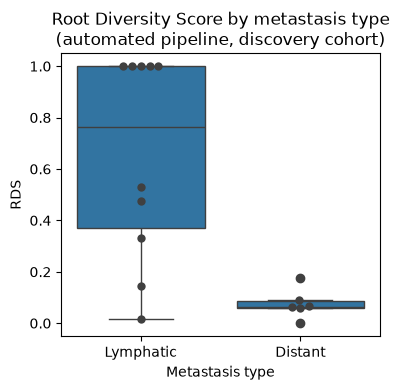

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(4, 4))
sns.boxplot(data=results_df, x="Metastasis type", y="RDS", order=["Lymphatic", "Distant"], ax=ax)
sns.swarmplot(data=results_df, x="Metastasis type", y="RDS", order=["Lymphatic", "Distant"],
              color=".25", size=6, ax=ax)
ax.set_ylim(-0.05, 1.05)
ax.set_title("Root Diversity Score by metastasis type\n(automated pipeline, discovery cohort)")
plt.tight_layout()

# Optional: Save as PDF for publication
# Save the plot at high resolution
plt.savefig(
    'Root_diversity_score.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()